<a href="https://colab.research.google.com/github/adrianIT96/Flask-Email-Analyzer/blob/main/Crypto_Sentiment_Analysis_Fear_%26_Greed_vs_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install yfinance if not already present
!pip install yfinance

import pandas as pd
import yfinance as yf
import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Environment is ready!")

Environment is ready!


In [3]:
# Fetch Fear & Greed Index data from API
url = 'https://api.alternative.me/fng/?limit=100'
response = requests.get(url)
raw_data = response.json()['data']

# Create a DataFrame and clean the data
sentiment_df = pd.DataFrame(raw_data)
sentiment_df['value'] = sentiment_df['value'].astype(float)
sentiment_df['timestamp'] = pd.to_datetime(sentiment_df['timestamp'], unit='s')

# Rename columns for clarity and set date as index
sentiment_df = sentiment_df[['timestamp', 'value']].rename(columns={'timestamp': 'Date', 'value': 'FNG_Index'})
sentiment_df.set_index('Date', inplace=True)

print("Recent Sentiment Data (Head):")
print(sentiment_df.head())

Recent Sentiment Data (Head):
            FNG_Index
Date                 
2026-03-09        8.0
2026-03-08       12.0
2026-03-07       12.0
2026-03-06       18.0
2026-03-05       22.0


/tmp/ipykernel_367/1920203613.py:9: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  sentiment_df['timestamp'] = pd.to_datetime(sentiment_df['timestamp'], unit='s')


In [6]:
# KROK 3 - UPDATED
# Download Bitcoin historical prices
start_date = sentiment_df.index.min()
end_date = sentiment_df.index.max()

btc_data = yf.download('BTC-USD', start=start_date, end=end_date)

# This is the FIX: Flatten the MultiIndex columns if they exist
if isinstance(btc_data.columns, pd.MultiIndex):
    btc_data.columns = btc_data.columns.get_level_values(0)

# Now keep only the 'Close' price
price_df = btc_data[['Close']].copy()

print("Recent Price Data (Head) - CLEANED:")
print(price_df.head())

/tmp/ipykernel_367/2303613633.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_data = yf.download('BTC-USD', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Recent Price Data (Head) - CLEANED:
Price              Close
Date                    
2025-11-30  90394.312500
2025-12-01  86321.570312
2025-12-02  91350.203125
2025-12-03  93527.804688
2025-12-04  92141.625000


In [7]:
# Merge both dataframes based on the Date index
merged_df = sentiment_df.join(price_df).dropna()

# Prepare features (X) and target (y)
# Reshaping X is required by Scikit-Learn
X = merged_df[['FNG_Index']].values
y = merged_df['Close'].values

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Generate predictions for the trend line
y_pred = model.predict(X)

print(f"Model Training Complete.")
print(f"Model Weight (w): {model.coef_[0]:.2f}")
print(f"Model Bias (b): {model.intercept_:.2f}")

Model Training Complete.
Model Weight (w): 768.63
Model Bias (b): 65965.56


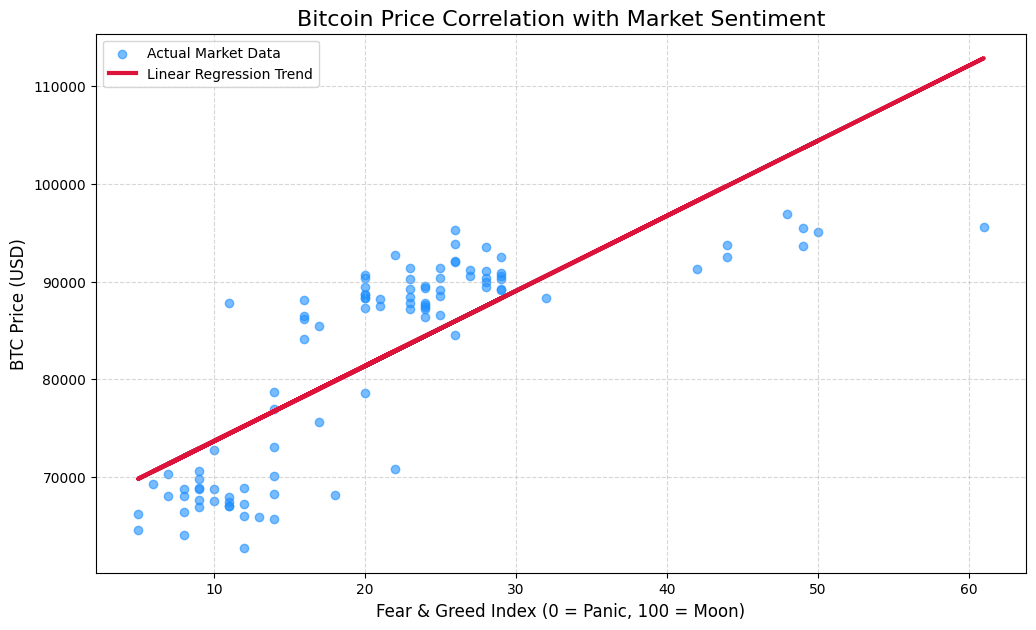

In [8]:
# KROK 5 - Visualization
import matplotlib.pyplot as plt

# Create a professional looking plot
plt.figure(figsize=(12, 7))

# Plot the actual market data points
plt.scatter(X, y, color='dodgerblue', alpha=0.6, label='Actual Market Data')

# Plot the regression line (the "prediction")
plt.plot(X, y_pred, color='crimson', linewidth=3, label='Linear Regression Trend')

# Add real-world context and styling
plt.title('Bitcoin Price Correlation with Market Sentiment', fontsize=16)
plt.xlabel('Fear & Greed Index (0 = Panic, 100 = Moon)', fontsize=12)
plt.ylabel('BTC Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()